# TP CNN — MNIST (NSI)

Objectif : comprendre, tester et comparer plusieurs architectures de réseaux de neurones convolutifs.

## <u>I/ Entraînement et optimisation du modèle</u>

## 1. Installation / Imports

In [ ]:
!python -m pip install pillow matplotlib

In [1]:

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt


## 2. Chargement des données

In [2]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()


## 3. Prétraitement

In [3]:

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)


## 4. Fonction de création du modèle

In [4]:

def creer_modele(nb_dense=64, dropout=False, nb_conv=2):
    model = models.Sequential()
    model.add(layers.Input(shape=(28,28,1)))

    model.add(layers.Conv2D(32,(3,3),activation="relu")) # "relu" = max(0,val), pour une classification
                                                         # Autres possibilités "Sigmoïd" = probabilité pour un test binaire
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64,(3,3),activation="relu"))
    model.add(layers.MaxPooling2D((2,2)))

    if nb_conv==3:
        model.add(layers.Conv2D(128,(3,3),activation="relu"))

    model.add(layers.Flatten())
    model.add(layers.Dense(nb_dense,activation="relu"))

    if dropout:
        model.add(layers.Dropout(0.3))

    model.add(layers.Dense(10,activation="softmax")) # "softmax" = probabilité par sortie

    model.compile(optimizer="adam",  # optimizer = calcul de la modifie les poids des neurones,"adam" = selon l'algo de la descente de gradient. 
                                     # Autres possibilités "sge" (descente de gradient simple), "adamax" (variante de "adam").
                  loss="sparse_categorical_crossentropy",  # loss = calcul de l'erreur du modèle ; "sparse_categorical_crossentropy" = par catégorie.
                                     # Autres possibilités "binary_crossentropy" = sortie binaire", "mse" = par regression (erreur quadratique).
                  metrics=["accuracy"]) # metrics = évaluation du modèle, "accuracy" = classification, 
                                     # Autres possibilités "precision" = faux positifs, "recall" = faux négatifs, "AUC" = classification probabiliste.
    return model


## 5. Fonction entraînement

In [10]:

def train(model):
    return model.fit(
        x_train,
        y_train,
        epochs=15,    # nombre d'entraînements max par image
        batch_size=32,  # nombre d'images par groupe traité
        validation_split=0.1, # fréquence de non utilisation de neurones
        verbose=1   # affiche chaque epoch et les résultats
    )


## 6. Fonction affichage

In [6]:

def plot(histories, metric, title):
    plt.figure(figsize=(8,4))
    for name,h in histories.items():
        plt.plot(h.history[metric],label=name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid()
    plt.show()



### Remarque importante

Dans les expériences suivantes, l'entraînement s'affiche **epoch par epoch** grâce à `verbose=1`.

Ainsi, on voit bien que le programme fonctionne et on peut suivre :
- la `loss`
- la `accuracy`
- la `val_loss`
- la `val_accuracy`


## 7. Test Conv2D

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9520 - loss: 0.1550 - val_accuracy: 0.9852 - val_loss: 0.0538
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9848 - loss: 0.0494 - val_accuracy: 0.9875 - val_loss: 0.0433
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9888 - loss: 0.0341 - val_accuracy: 0.9893 - val_loss: 0.0355
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9921 - loss: 0.0237 - val_accuracy: 0.9897 - val_loss: 0.0375
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9937 - loss: 0.0189 - val_accuracy: 0.9903 - val_loss: 0.0348
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9949 - loss: 0.0151 - val_accuracy: 0.9902 - val_loss: 0.0382
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9962 - loss: 0.0115 - val_accuracy: 0.9908 - val_loss: 0.0441
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9964 - loss: 0

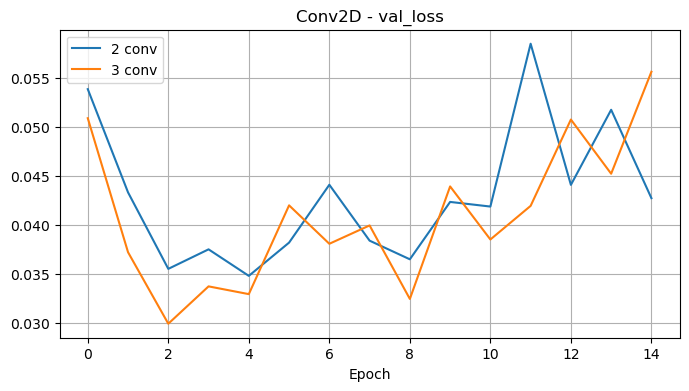

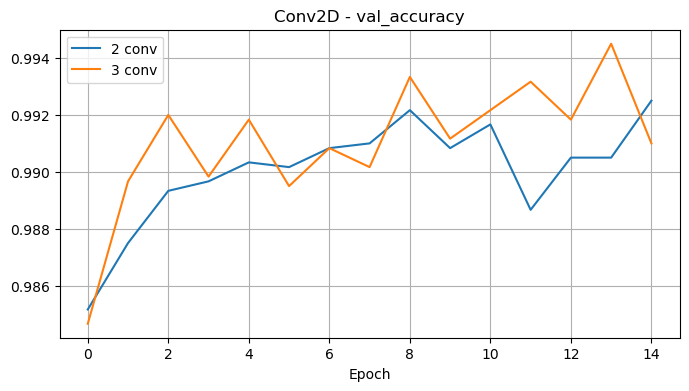

In [11]:

hist_conv={}
hist_conv["2 conv"]=train(creer_modele(nb_conv=2))
hist_conv["3 conv"]=train(creer_modele(nb_conv=3))

plot(hist_conv,"val_loss","Conv2D - val_loss")
plot(hist_conv,"val_accuracy","Conv2D - val_accuracy")


## 8. Test Dense

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9491 - loss: 0.1660 - val_accuracy: 0.9832 - val_loss: 0.0528
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9828 - loss: 0.0557 - val_accuracy: 0.9830 - val_loss: 0.0586
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9874 - loss: 0.0405 - val_accuracy: 0.9850 - val_loss: 0.0533
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9903 - loss: 0.0302 - val_accuracy: 0.9878 - val_loss: 0.0413
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9926 - loss: 0.0226 - val_accuracy: 0.9897 - val_loss: 0.0377
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9937 - loss: 0.0179 - val_accuracy: 0.9910 - val_loss: 0.0392
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9954 - loss: 0.0143 - val_accuracy: 0.9893 - val_loss: 0.0403
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9960 - loss: 0

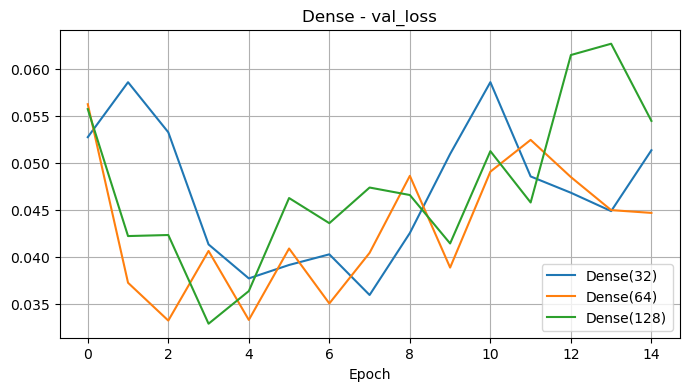

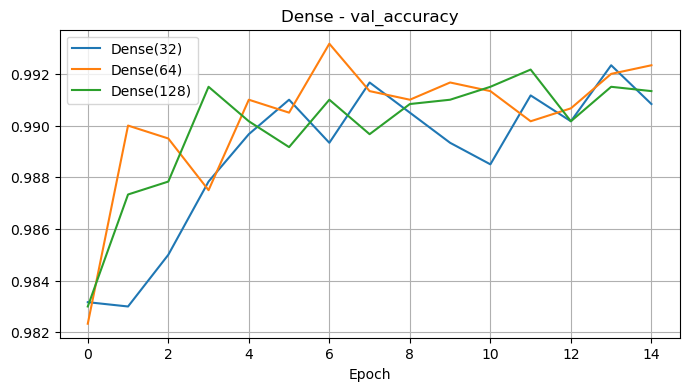

In [12]:

hist_dense={}
for n in [32,64,128]:
    hist_dense[f"Dense({n})"]=train(creer_modele(nb_dense=n))

plot(hist_dense,"val_loss","Dense - val_loss")
plot(hist_dense,"val_accuracy","Dense - val_accuracy")


## 9. Test Dropout

In [ ]:

hist_drop={}
hist_drop["sans"]=train(creer_modele(dropout=False))
hist_drop["avec"]=train(creer_modele(dropout=True))

plot(hist_drop,"val_loss","Dropout - val_loss")
plot(hist_drop,"val_accuracy","Dropout - val_accuracy")


## 10. Sauvegarde modèle

In [ ]:
##################################################################################
################# ENTRAINEMENT ET SAUVEGARDE DU MODELE ###########################
##################################################################################

nb_dense = 32     # Mettre la valeur de densité souhaitée : 32 , 64 ou 128
dropout = False   # Mettre si dropout est souhaité (True) ou pas (False)
epochs = 2        # Mettre le nombre de tours d'entraînement voulu.


model_final = creer_modele(nb_dense, dropout)
model_final.fit(x_train,y_train,epochs)
model_final.save("cnn_mnist.h5")
print("Modèle sauvegardé")


## <u>II/ Application à la reconnaissance des chiffres</u>

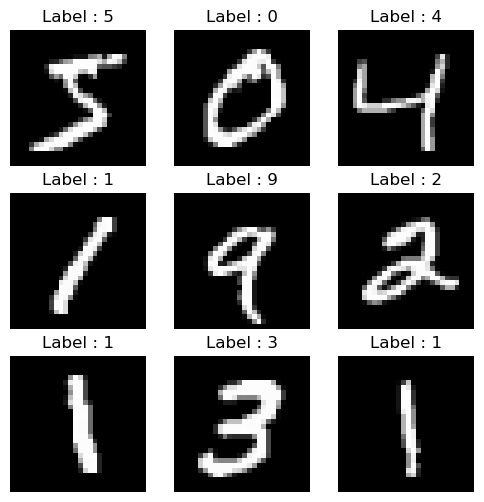

In [6]:
# Visualisation de quelques données du modèle mndist
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Chargement des données
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Affichage de quelques images
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label : {y_train[i]}")
    plt.axis("off")

plt.show()

In [10]:
# Programme permettant de tester des chiffres à main levée

import tkinter as tk
from PIL import Image, ImageDraw, ImageTk, ImageFilter
import numpy as np
import tensorflow as tf

# ============================================================
# Chargement du modèle
# ============================================================
model = tf.keras.models.load_model("cnn_mnist.h5", compile=False)

# ============================================================
# Paramètres
# ============================================================
SIZE = 280
BRUSH_SIZE = 18

# ============================================================
# Fenêtre
# ============================================================
root = tk.Tk()
root.title("MNIST - Dessin")

# Canvas (zone de dessin)
canvas = tk.Canvas(root, width=SIZE, height=SIZE, bg="black")
canvas.grid(row=0, column=0, padx=10, pady=10)

# Image PIL associée
image = Image.new("L", (SIZE, SIZE), 0)
draw = ImageDraw.Draw(image)

last_x, last_y = None, None
preview_photo = None

# ============================================================
# Dessin
# ============================================================
def draw_line(event):
    global last_x, last_y

    x, y = event.x, event.y

    if last_x is not None:
        canvas.create_line(last_x, last_y, x, y,
                           fill="white",
                           width=BRUSH_SIZE,
                           capstyle=tk.ROUND)

        draw.line([last_x, last_y, x, y],
                  fill=255,
                  width=BRUSH_SIZE)

    last_x, last_y = x, y


def reset(event):
    global last_x, last_y
    last_x, last_y = None, None


canvas.bind("<B1-Motion>", draw_line)
canvas.bind("<ButtonRelease-1>", reset)

# ============================================================
# Prétraitement
# ============================================================
def preprocess(img):
    arr = np.array(img)

    coords = np.argwhere(arr > 20)

    if coords.size == 0:
        return np.zeros((1,28,28,1)), np.zeros((28,28))

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    cropped = arr[y_min:y_max+1, x_min:x_max+1]
    cropped_img = Image.fromarray(cropped)

    cropped_img.thumbnail((20,20))

    final_img = Image.new("L", (28,28), 0)
    paste_x = (28 - cropped_img.width)//2
    paste_y = (28 - cropped_img.height)//2
    final_img.paste(cropped_img, (paste_x, paste_y))

    #### AJOUTER ICI LE FLOU GAUSSIEN ##########
    final_img = final_img.filter(ImageFilter.GaussianBlur(radius=1))
    ############################################

    arr = np.array(final_img)/255.0

    return arr.reshape(1,28,28,1), arr

# ============================================================
# Aperçu 28x28
# ============================================================
def show_preview(img28):
    global preview_photo

    img = (img28*255).astype(np.uint8)
    pil_img = Image.fromarray(img)

    pil_img = pil_img.resize((140,140), Image.NEAREST)

    preview_photo = ImageTk.PhotoImage(pil_img)
    preview_label.config(image=preview_photo)
    preview_label.image = preview_photo

# ============================================================
# Prédiction
# ============================================================
def predict():
    img_tensor, img28 = preprocess(image)

    proba = model.predict(img_tensor, verbose=0)[0]
    digit = np.argmax(proba)

    text = f"Prédiction : {digit}\n"
    text += " ".join(f"{i}:{proba[i]:.2f}" for i in range(10))

    result_label.config(text=text)

    show_preview(img28)

# ============================================================
# Clear
# ============================================================
def clear():
    canvas.delete("all")
    draw.rectangle([0,0,SIZE,SIZE], fill=0)
    result_label.config(text="")
    preview_label.config(image="")

# ============================================================
# UI droite
# ============================================================
right_frame = tk.Frame(root)
right_frame.grid(row=0, column=1, padx=10)

preview_label = tk.Label(right_frame)
preview_label.pack()

result_label = tk.Label(right_frame, text="", justify="left")
result_label.pack(pady=10)

tk.Button(right_frame, text="Prédire", command=predict).pack(fill="x")
tk.Button(right_frame, text="Effacer", command=clear).pack(fill="x")

# ============================================================
# Lancement
# ============================================================
root.mainloop()